# Decision Trees: Intuitive, Interpretable, and Powerful

**Learning Objectives:**
- Understand the intuition behind **decision trees** and how they make predictions
- Learn how trees split data using **impurity measures** (Gini, Entropy)
- Visualize decision boundaries and tree structures
- Understand **overfitting** and how to control it with **regularization**
- Build strong intuitions about hyperparameter tuning
- Know when decision trees are the right choice

By the end of this notebook, you'll have **deep intuitions** about decision trees — the foundation for powerful ensemble methods like Random Forests and Gradient Boosting.


## Part 1: Why Decision Trees Matter

Decision trees are one of the most **intuitive** and **interpretable** machine learning algorithms. They're important because:

1. **Human-readable** — You can explain predictions to non-technical stakeholders
2. **No feature scaling needed** — Works with raw data directly
3. **Handles mixed data types** — Numerical and categorical features together
4. **Captures non-linear patterns** — Without explicit feature engineering
5. **Foundation for ensembles** — Random Forests, Gradient Boosting, XGBoost all use trees

### Real-World Applications

- **Medical diagnosis** — Interpretable rules doctors can understand
- **Credit scoring** — Explainable decisions required by regulations
- **Customer segmentation** — Clear groupings based on features
- **Fraud detection** — Identifying suspicious patterns
- **Manufacturing** — Quality control decision rules


## Part 2: Setup

### Configuration

All hyperparameters in one place for easy experimentation.


In [1]:
CONFIG = {
    # Reproducibility
    'seed': 42,  # Random seed for reproducibility
    
    # Data
    'n_samples': 300,  # Number of samples for synthetic datasets
    'test_size': 0.2,  # Fraction of data for testing
    'noise': 0.15,  # Noise level for synthetic data
    
    # Tree Hyperparameters
    'max_depth': None,  # Maximum depth of tree (None = unlimited)
    'min_samples_split': 2,  # Minimum samples required to split a node
    'min_samples_leaf': 1,  # Minimum samples required in a leaf node
    'criterion': 'gini',  # Splitting criterion: 'gini' or 'entropy'
}


### Random Seed & Imports


In [2]:
from aiml_notebooks import set_seed
import numpy as np

set_seed(CONFIG['seed'])

print(f"✓ Seed set to {CONFIG['seed']} for reproducibility")


✓ Seed set to 42 for reproducibility


In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


## Part 3: The Intuition — Playing 20 Questions

Have you ever played "20 Questions"? The game where someone thinks of an object and you try to guess it by asking yes/no questions?

**That's exactly how decision trees work!**

The tree asks a series of questions about the features:
- "Is age > 30?"
- "Is income > 50K?"
- "Is the petal length > 2.5 cm?"

Each answer narrows down the possibilities until we reach a prediction.

### A Simple Example

Let's say we want to predict if someone will buy a product based on their age and income:


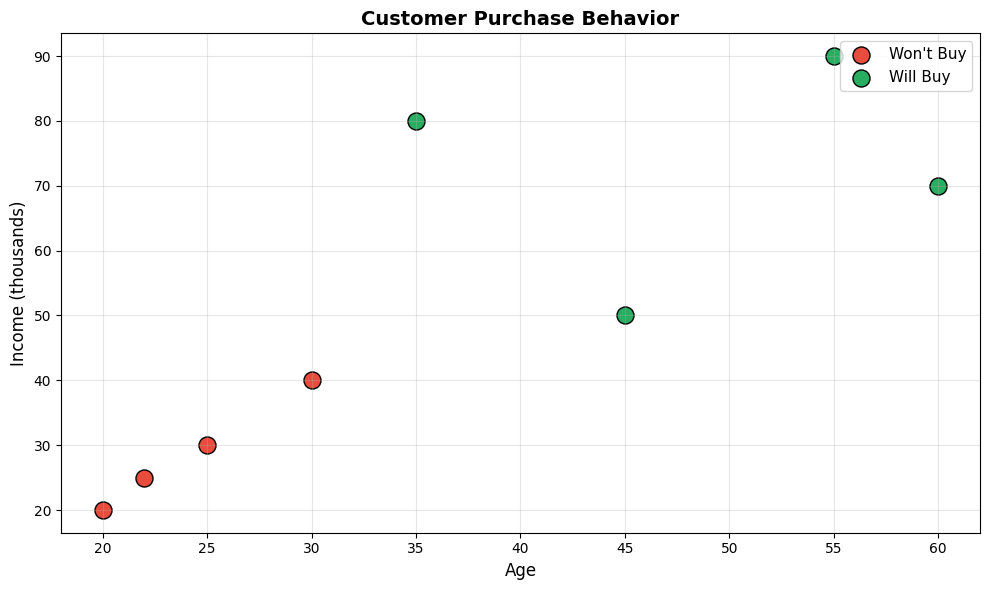

In [4]:
# Create a simple dataset
# Features: [age, income_in_thousands]
# Target: 1 = will buy, 0 = won't buy

X_simple = np.array([
    [25, 30],   # Young, low income
    [35, 80],   # Middle-aged, high income
    [45, 50],   # Middle-aged, medium income
    [20, 20],   # Young, very low income
    [55, 90],   # Older, high income
    [30, 40],   # Young-ish, medium income
    [60, 70],   # Older, medium-high income
    [22, 25],   # Young, low income
])

y_simple = np.array([0, 1, 1, 0, 1, 0, 1, 0])

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_simple[y_simple == 0, 0], X_simple[y_simple == 0, 1], 
            c='#e74c3c', s=150, label='Won\'t Buy', edgecolors='black', linewidth=1)
plt.scatter(X_simple[y_simple == 1, 0], X_simple[y_simple == 1, 1], 
            c='#27ae60', s=150, label='Will Buy', edgecolors='black', linewidth=1)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Income (thousands)', fontsize=12)
plt.title('Customer Purchase Behavior', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Now let's train a decision tree and see what questions it learns to ask:


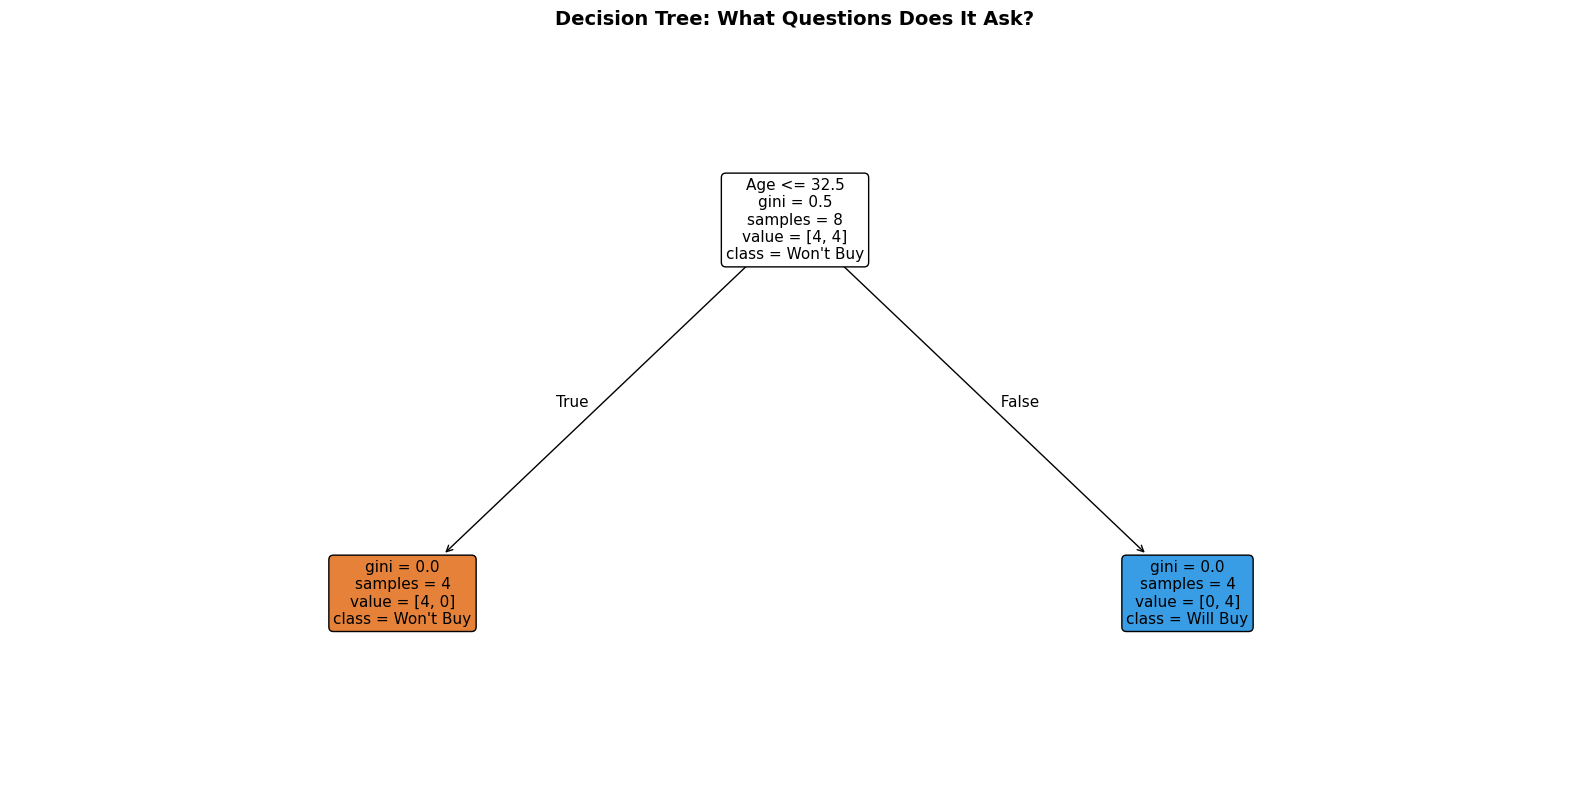

In [5]:
# Train a simple decision tree
tree_simple = DecisionTreeClassifier(max_depth=3, random_state=CONFIG['seed'])
tree_simple.fit(X_simple, y_simple)

# Visualize the tree
plt.figure(figsize=(16, 8))
plot_tree(tree_simple, 
          feature_names=['Age', 'Income'],
          class_names=['Won\'t Buy', 'Will Buy'],
          filled=True,
          rounded=True,
          fontsize=11)
plt.title('Decision Tree: What Questions Does It Ask?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Reading the Tree

Each box (node) shows:
- **Feature and threshold**: The question being asked (e.g., "Income <= 45?")
- **gini**: How "impure" the node is (we'll explain this soon!)
- **samples**: How many training examples reach this node
- **value**: Count of each class [won't buy, will buy]
- **class**: The majority class at this node

**Left branch = Yes (True)** | **Right branch = No (False)**


## Part 4: How Trees Make Splits — Impurity Measures

The key question: **How does the tree decide which feature and threshold to split on?**

The goal is to create splits that **separate the classes as cleanly as possible**.

We measure "cleanness" using **impurity measures**:

### Gini Impurity

Gini impurity measures how often a randomly chosen element would be incorrectly classified:

$$\text{Gini}(D) = 1 - \sum_{i=1}^{C} p_i^2$$

where $p_i$ is the proportion of class $i$ in the dataset $D$.

- **Gini = 0**: Perfect purity (all samples belong to one class)
- **Gini = 0.5**: Maximum impurity for binary classification (50-50 split)

### Entropy (Information Gain)

Entropy comes from information theory and measures uncertainty:

$$\text{Entropy}(D) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

- **Entropy = 0**: Perfect purity
- **Entropy = 1**: Maximum uncertainty for binary classification

Let's visualize both:


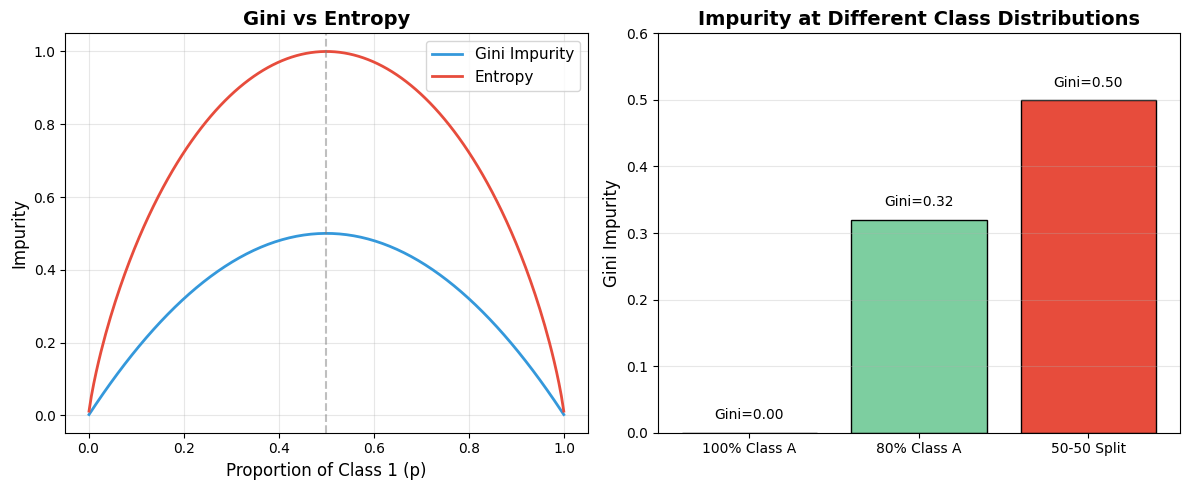

💡 Key Insight: Both measures are minimized when classes are perfectly separated!
   The tree tries to find splits that reduce impurity the most.


In [6]:
def gini(p):
    """Gini impurity for binary classification."""
    return 1 - p**2 - (1-p)**2

def entropy(p):
    """Entropy for binary classification."""
    # Handle edge cases
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

# Plot both measures
p_values = np.linspace(0.001, 0.999, 200)
gini_values = [gini(p) for p in p_values]
entropy_values = [entropy(p) for p in p_values]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(p_values, gini_values, linewidth=2, color='#3498db', label='Gini Impurity')
plt.plot(p_values, entropy_values, linewidth=2, color='#e74c3c', label='Entropy')
plt.xlabel('Proportion of Class 1 (p)', fontsize=12)
plt.ylabel('Impurity', fontsize=12)
plt.title('Gini vs Entropy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
# Show what different impurity values mean
scenarios = [
    (0.0, '100% Class A', '#27ae60'),
    (0.2, '80% Class A', '#7dcea0'),
    (0.5, '50-50 Split', '#e74c3c'),
]
for p, label, color in scenarios:
    plt.bar(label, gini(p), color=color, edgecolor='black', linewidth=1)
    plt.text(label, gini(p) + 0.02, f'Gini={gini(p):.2f}', ha='center', fontsize=10)

plt.ylabel('Gini Impurity', fontsize=12)
plt.title('Impurity at Different Class Distributions', fontsize=14, fontweight='bold')
plt.ylim(0, 0.6)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("💡 Key Insight: Both measures are minimized when classes are perfectly separated!")
print("   The tree tries to find splits that reduce impurity the most.")


### Information Gain

When deciding on a split, the tree calculates the **information gain** — how much the split reduces impurity:

$$\text{Gain}(D, \text{split}) = \text{Impurity}(D) - \sum_{\text{child}} \frac{|D_{\text{child}}|}{|D|} \cdot \text{Impurity}(D_{\text{child}})$$

The split with the **highest information gain** is chosen!


In [7]:
def calculate_information_gain(parent_impurity, left_impurity, right_impurity, left_weight, right_weight):
    """Calculate information gain from a split."""
    weighted_child_impurity = left_weight * left_impurity + right_weight * right_impurity
    return parent_impurity - weighted_child_impurity

# Example: Suppose we have 10 samples (6 class A, 4 class B)
# Consider two possible splits:

print("Example: 10 samples (6 Class A, 4 Class B)")
print("Parent Gini: {:.3f}\n".format(gini(4/10)))

# Split 1: Left=[5A, 0B], Right=[1A, 4B]
print("Split 1: Left=[5A, 0B], Right=[1A, 4B]")
left_gini_1 = gini(0/5)  # All class A
right_gini_1 = gini(4/5)  # Mostly class B
gain_1 = calculate_information_gain(gini(4/10), left_gini_1, right_gini_1, 5/10, 5/10)
print(f"  Left Gini: {left_gini_1:.3f}, Right Gini: {right_gini_1:.3f}")
print(f"  Information Gain: {gain_1:.3f}\n")

# Split 2: Left=[3A, 2B], Right=[3A, 2B]
print("Split 2: Left=[3A, 2B], Right=[3A, 2B]")
left_gini_2 = gini(2/5)
right_gini_2 = gini(2/5)
gain_2 = calculate_information_gain(gini(4/10), left_gini_2, right_gini_2, 5/10, 5/10)
print(f"  Left Gini: {left_gini_2:.3f}, Right Gini: {right_gini_2:.3f}")
print(f"  Information Gain: {gain_2:.3f}\n")

print(f"🎯 Split 1 is better! Higher information gain ({gain_1:.3f} > {gain_2:.3f})")
print("   It creates purer child nodes.")


Example: 10 samples (6 Class A, 4 Class B)
Parent Gini: 0.480

Split 1: Left=[5A, 0B], Right=[1A, 4B]
  Left Gini: 0.000, Right Gini: 0.320
  Information Gain: 0.320

Split 2: Left=[3A, 2B], Right=[3A, 2B]
  Left Gini: 0.480, Right Gini: 0.480
  Information Gain: 0.000

🎯 Split 1 is better! Higher information gain (0.320 > 0.000)
   It creates purer child nodes.


## Part 5: Decision Boundaries — Axis-Aligned Splits

A key characteristic of decision trees: they create **axis-aligned** (rectangular) decision boundaries.

Each split is perpendicular to one feature axis (horizontal or vertical lines in 2D).

Let's visualize this:


In [8]:
def plot_decision_boundary(model, X, y, title="Decision Boundary", ax=None):
    """Plot decision boundary for 2D classification."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))
    
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    # Get predictions
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.contour(xx, yy, Z, colors='black', linewidths=1, alpha=0.5)
    
    # Plot data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
                         s=50, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    return ax


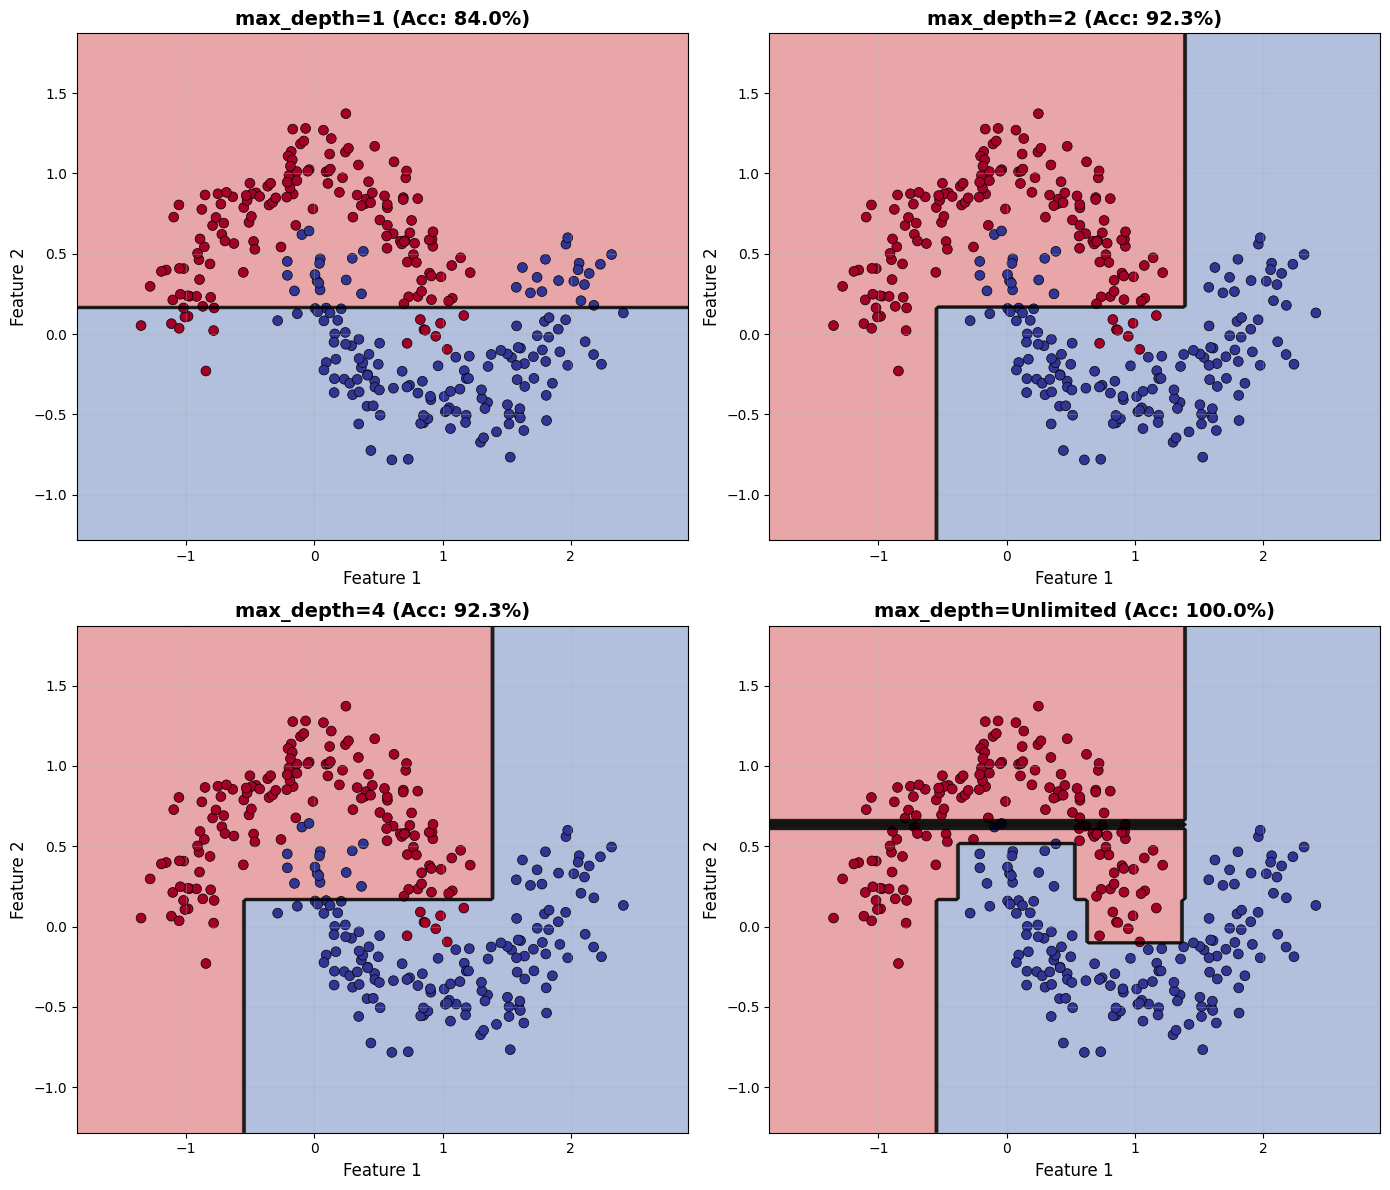

🔍 Key Observations:
  • Shallow trees (depth=1-2): Simple boundaries, might underfit
  • Deep trees (unlimited): Complex boundaries, might overfit
  • Notice the rectangular/axis-aligned nature of all boundaries!


In [9]:
# Generate a dataset
X, y = make_moons(n_samples=CONFIG['n_samples'], noise=CONFIG['noise'], random_state=CONFIG['seed'])

# Train trees with different depths
depths = [1, 2, 4, None]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, depth in zip(axes, depths):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=CONFIG['seed'])
    tree.fit(X, y)
    
    accuracy = tree.score(X, y)
    depth_str = str(depth) if depth else 'Unlimited'
    
    plot_decision_boundary(
        tree, X, y,
        f'max_depth={depth_str} (Acc: {accuracy:.1%})',
        ax=ax
    )

plt.tight_layout()
plt.show()

print("🔍 Key Observations:")
print("  • Shallow trees (depth=1-2): Simple boundaries, might underfit")
print("  • Deep trees (unlimited): Complex boundaries, might overfit")
print("  • Notice the rectangular/axis-aligned nature of all boundaries!")


### 💡 Key Insight: Axis-Aligned Splits

Decision trees can only make splits parallel to the axes. This means:

- **Advantage**: Easy to interpret ("if feature X > threshold, then...")
- **Disadvantage**: Need many splits to approximate diagonal boundaries
- **Solution**: Use deeper trees or ensemble methods (Random Forests)


## Part 6: Overfitting — The Curse of Deep Trees

Decision trees are **high-variance** models. Given enough depth, they can perfectly memorize the training data — including noise!

Let's demonstrate this problem:


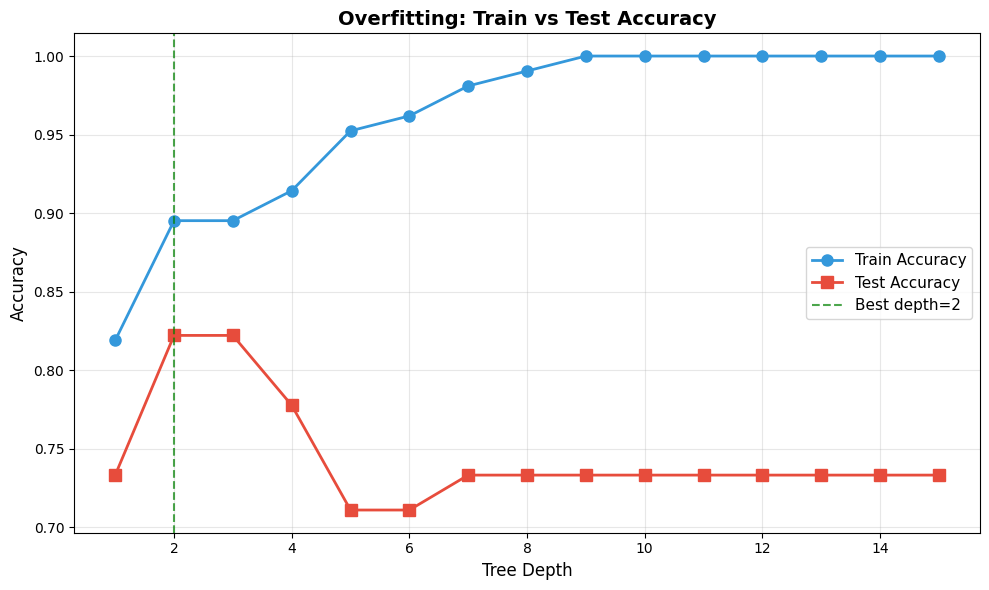

📊 Results:
   Best test accuracy: 82.2% at depth=2
   Deep tree (depth=15): Train=100.0%, Test=73.3%
   Gap at depth=15: 26.7% (overfitting!)


In [10]:
# Generate data with more noise
X_noisy, y_noisy = make_moons(n_samples=150, noise=0.3, random_state=CONFIG['seed'])
X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y_noisy, test_size=0.3, random_state=CONFIG['seed']
)

# Train trees with different depths
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=CONFIG['seed'])
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', label='Train Accuracy', linewidth=2, markersize=8, color='#3498db')
plt.plot(depths, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8, color='#e74c3c')
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overfitting: Train vs Test Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Mark the overfitting region
best_test_depth = list(depths)[np.argmax(test_scores)]
plt.axvline(x=best_test_depth, color='green', linestyle='--', alpha=0.7, 
            label=f'Best depth={best_test_depth}')

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"📊 Results:")
print(f"   Best test accuracy: {max(test_scores):.1%} at depth={best_test_depth}")
print(f"   Deep tree (depth=15): Train={train_scores[-1]:.1%}, Test={test_scores[-1]:.1%}")
print(f"   Gap at depth=15: {train_scores[-1] - test_scores[-1]:.1%} (overfitting!)")


### Visualizing Overfitting


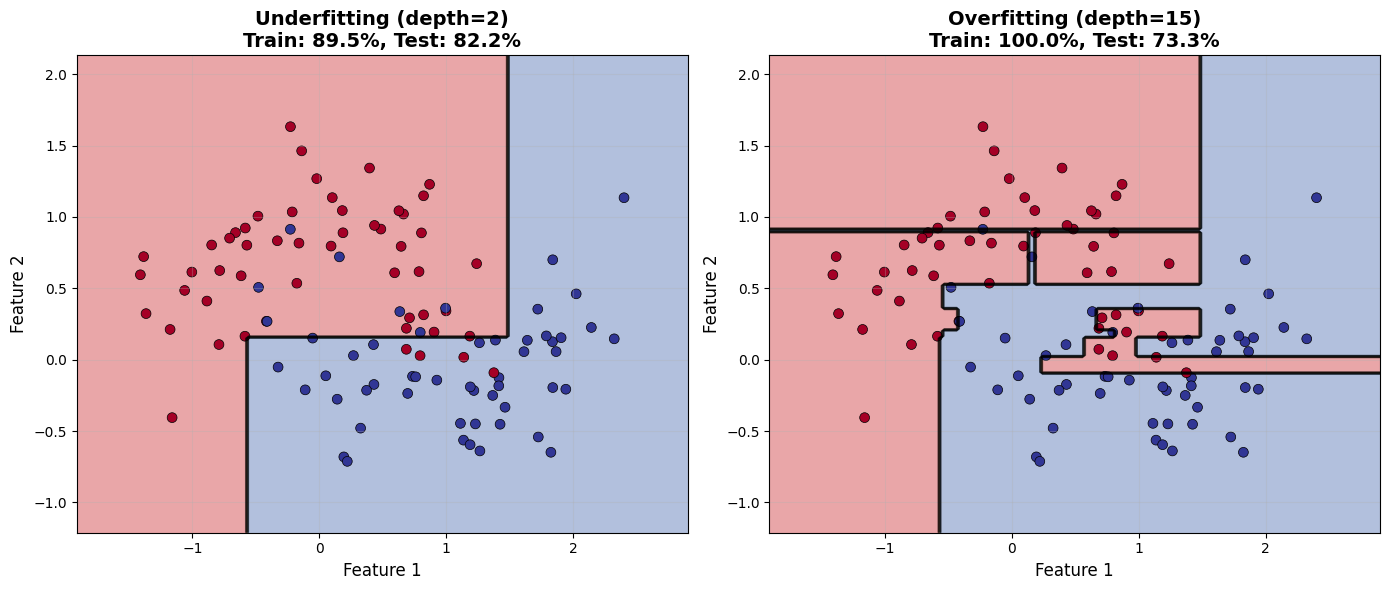

🔍 Notice:
  • Shallow tree: Smooth but misses the moon pattern
  • Deep tree: Captures every detail, including noise!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Underfitting (too shallow)
tree_shallow = DecisionTreeClassifier(max_depth=2, random_state=CONFIG['seed'])
tree_shallow.fit(X_train, y_train)
plot_decision_boundary(
    tree_shallow, X_train, y_train,
    f'Underfitting (depth=2)\nTrain: {tree_shallow.score(X_train, y_train):.1%}, Test: {tree_shallow.score(X_test, y_test):.1%}',
    ax=axes[0]
)

# Overfitting (too deep)
tree_deep = DecisionTreeClassifier(max_depth=15, random_state=CONFIG['seed'])
tree_deep.fit(X_train, y_train)
plot_decision_boundary(
    tree_deep, X_train, y_train,
    f'Overfitting (depth=15)\nTrain: {tree_deep.score(X_train, y_train):.1%}, Test: {tree_deep.score(X_test, y_test):.1%}',
    ax=axes[1]
)

plt.tight_layout()
plt.show()

print("🔍 Notice:")
print("  • Shallow tree: Smooth but misses the moon pattern")
print("  • Deep tree: Captures every detail, including noise!")


## Part 7: Regularization — Controlling Tree Complexity

To prevent overfitting, we can **regularize** the tree by limiting its complexity.

### Key Hyperparameters for Regularization

| Parameter | Effect | Typical Values |
|-----------|--------|----------------|
| `max_depth` | Maximum depth of the tree | 3-10 for most problems |
| `min_samples_split` | Minimum samples to split a node | 2-20 |
| `min_samples_leaf` | Minimum samples in a leaf | 1-10 |
| `max_features` | Number of features to consider per split | sqrt(n_features), log2(n_features) |
| `max_leaf_nodes` | Maximum number of leaf nodes | Varies |

Let's explore these:


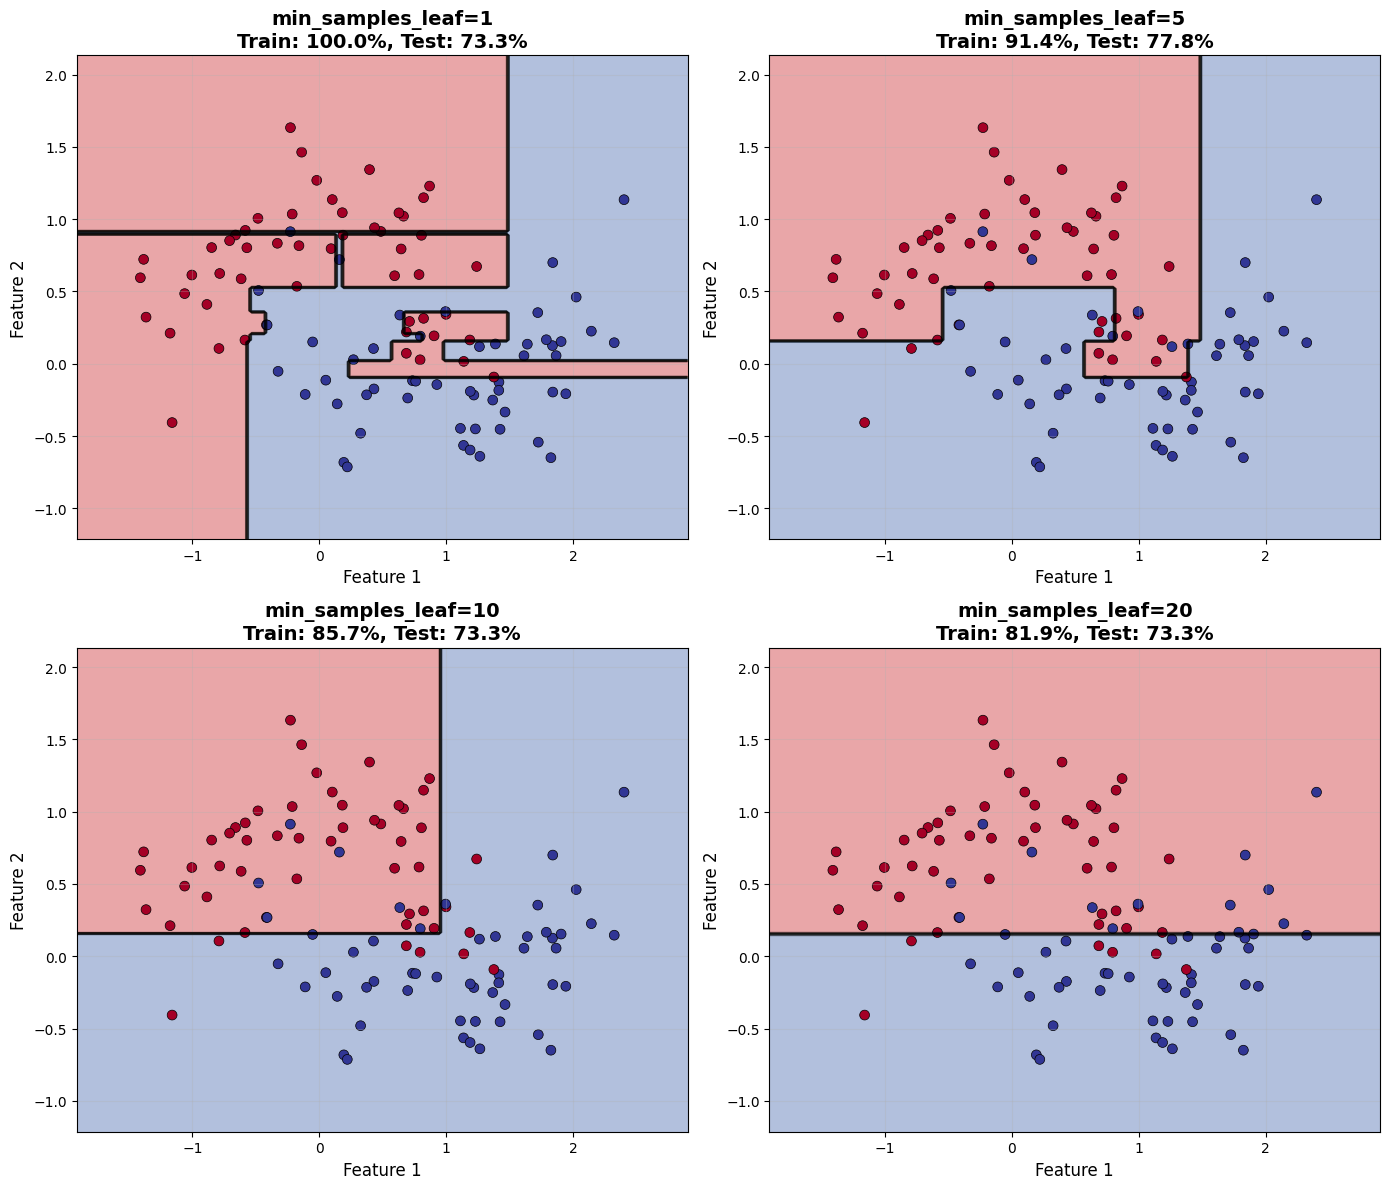

💡 Insight: Higher min_samples_leaf = smoother boundaries = less overfitting


In [12]:
# Effect of min_samples_leaf
min_samples_values = [1, 5, 10, 20]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, min_samples in zip(axes, min_samples_values):
    tree = DecisionTreeClassifier(
        min_samples_leaf=min_samples,
        random_state=CONFIG['seed']
    )
    tree.fit(X_train, y_train)
    
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    
    plot_decision_boundary(
        tree, X_train, y_train,
        f'min_samples_leaf={min_samples}\nTrain: {train_acc:.1%}, Test: {test_acc:.1%}',
        ax=ax
    )

plt.tight_layout()
plt.show()

print("💡 Insight: Higher min_samples_leaf = smoother boundaries = less overfitting")


### Comparing Regularization Strategies


In [13]:
# Generate a larger dataset for proper comparison
X_large, y_large = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=CONFIG['seed']
)
X_tr, X_te, y_tr, y_te = train_test_split(X_large, y_large, test_size=0.3, random_state=CONFIG['seed'])

# Test different configurations
configs = [
    {'name': 'No Regularization', 'params': {}},
    {'name': 'max_depth=5', 'params': {'max_depth': 5}},
    {'name': 'min_samples_leaf=10', 'params': {'min_samples_leaf': 10}},
    {'name': 'min_samples_split=20', 'params': {'min_samples_split': 20}},
    {'name': 'max_leaf_nodes=20', 'params': {'max_leaf_nodes': 20}},
    {'name': 'Combined', 'params': {'max_depth': 8, 'min_samples_leaf': 5}},
]

print("Regularization Comparison")
print("=" * 60)
print(f"{'Configuration':<25} {'Train Acc':>12} {'Test Acc':>12} {'Gap':>10}")
print("-" * 60)

results = []
for config in configs:
    tree = DecisionTreeClassifier(random_state=CONFIG['seed'], **config['params'])
    tree.fit(X_tr, y_tr)
    
    train_acc = tree.score(X_tr, y_tr)
    test_acc = tree.score(X_te, y_te)
    gap = train_acc - test_acc
    
    results.append({'name': config['name'], 'train': train_acc, 'test': test_acc, 'gap': gap})
    print(f"{config['name']:<25} {train_acc:>12.1%} {test_acc:>12.1%} {gap:>10.1%}")

print("=" * 60)
print("\n✓ Lower gap = less overfitting")


Regularization Comparison
Configuration                Train Acc     Test Acc        Gap
------------------------------------------------------------
No Regularization               100.0%        81.7%      18.3%
max_depth=5                      91.1%        83.3%       7.8%
min_samples_leaf=10              90.0%        81.7%       8.3%
min_samples_split=20             94.6%        81.7%      12.9%
max_leaf_nodes=20                91.4%        83.7%       7.8%
Combined                         94.4%        82.3%      12.1%

✓ Lower gap = less overfitting


## Part 8: Feature Importance — What Features Matter?

One of the best things about decision trees: they naturally provide **feature importance** scores!

Feature importance is calculated based on how much each feature reduces impurity across all splits.


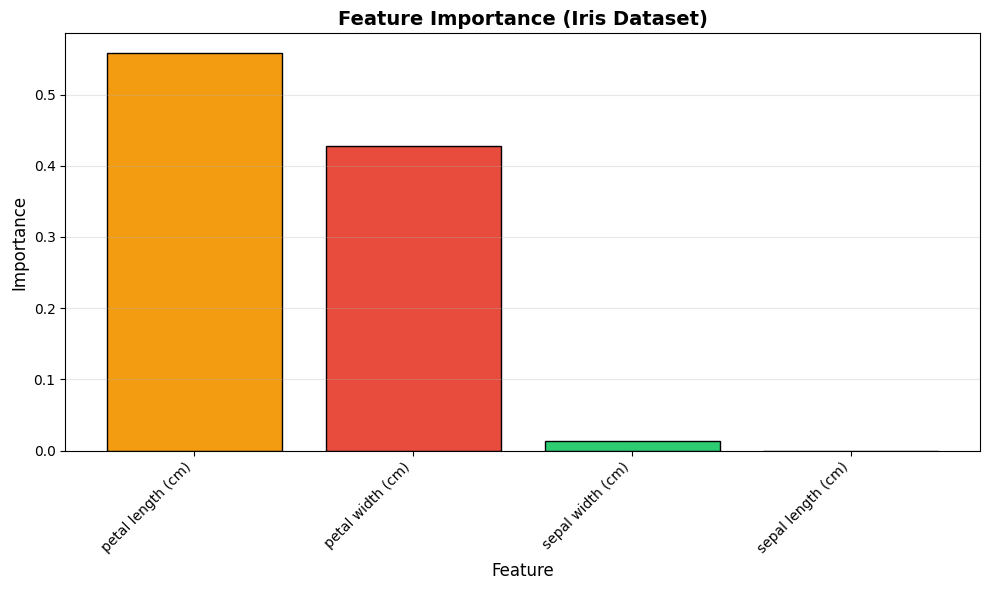

Feature Importance Ranking:
  petal length (cm): 0.5582
  petal width (cm): 0.4283
  sepal width (cm): 0.0135
  sepal length (cm): 0.0000


In [14]:
from sklearn.datasets import load_iris

# Load iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Train a tree
tree_iris = DecisionTreeClassifier(max_depth=4, random_state=CONFIG['seed'])
tree_iris.fit(X_iris, y_iris)

# Get feature importances
importances = tree_iris.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
plt.bar(range(len(importances)), importances[indices], color=[colors[i] for i in indices], edgecolor='black')
plt.xticks(range(len(importances)), [iris.feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title('Feature Importance (Iris Dataset)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
for i in indices:
    print(f"  {iris.feature_names[i]}: {importances[i]:.4f}")


### Visualizing the Tree Structure


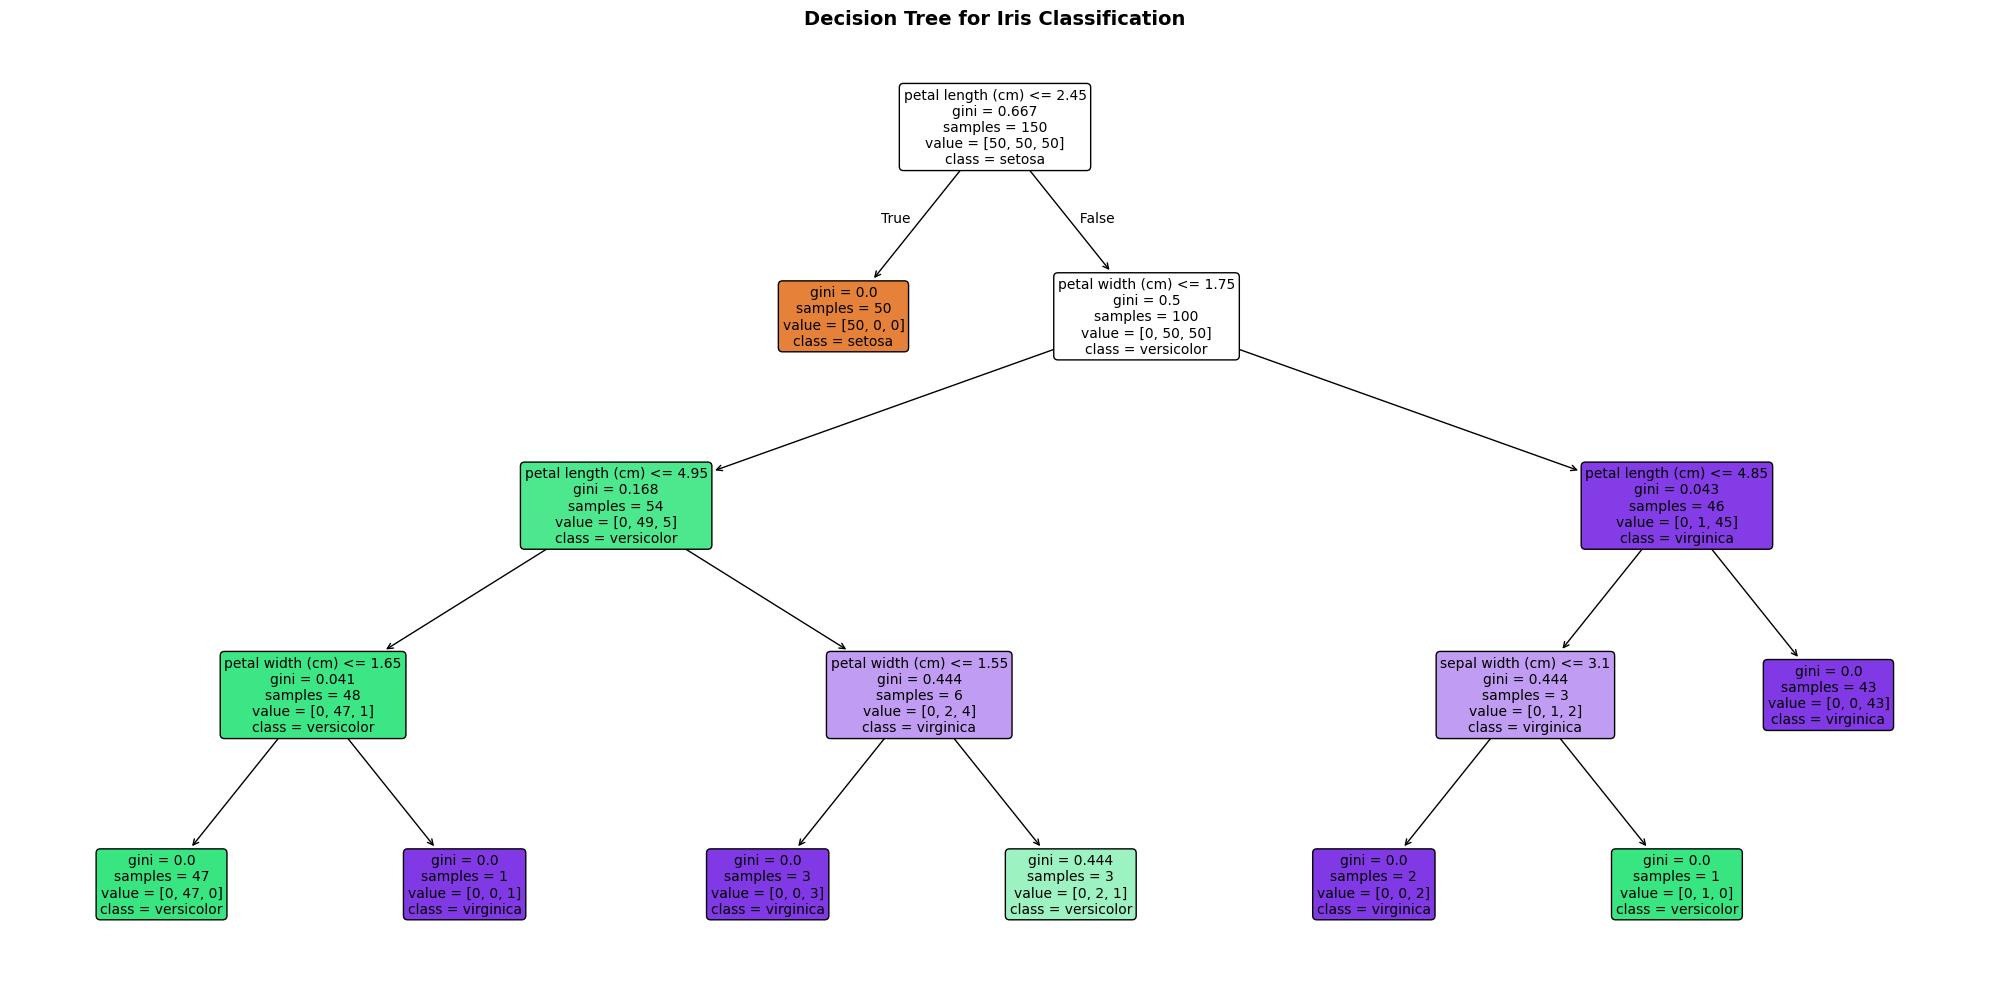

In [15]:
plt.figure(figsize=(20, 10))
plot_tree(tree_iris, 
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree for Iris Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 9: Decision Trees for Regression

Decision trees aren't just for classification! They can also predict continuous values.

**Key differences:**
- Instead of Gini/Entropy, use **MSE** (Mean Squared Error) or **MAE** (Mean Absolute Error)
- Leaf predictions are the **mean** of training samples in that leaf


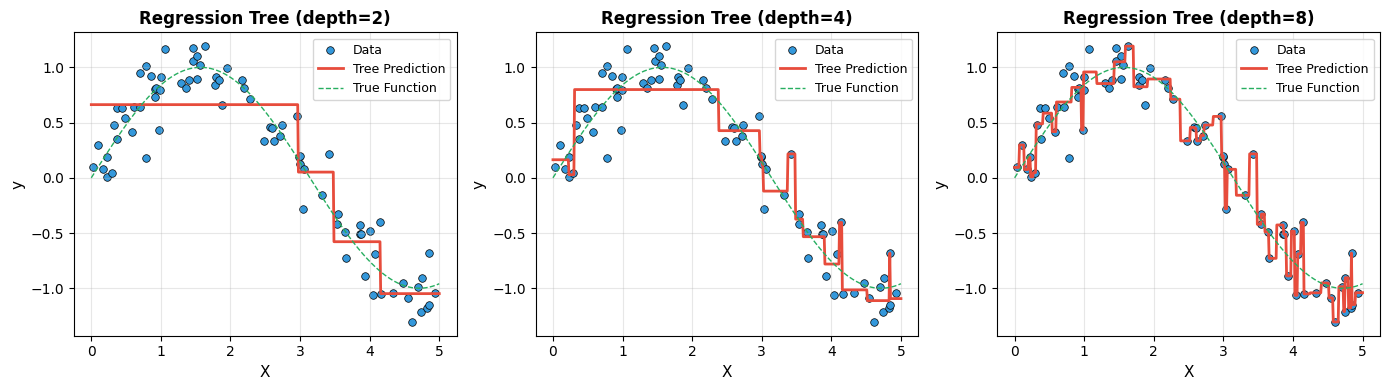

🔍 Notice: Regression trees create step-like predictions!
   Deeper trees = more steps = finer approximation


In [16]:
# Generate regression data
np.random.seed(CONFIG['seed'])
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.randn(80) * 0.2

# Train trees with different depths
depths = [2, 4, 8]

plt.figure(figsize=(14, 4))

for i, depth in enumerate(depths, 1):
    plt.subplot(1, 3, i)
    
    tree = DecisionTreeRegressor(max_depth=depth, random_state=CONFIG['seed'])
    tree.fit(X_reg, y_reg)
    
    # Generate predictions for smooth line
    X_test_reg = np.linspace(0, 5, 500).reshape(-1, 1)
    y_pred = tree.predict(X_test_reg)
    
    plt.scatter(X_reg, y_reg, s=30, c='#3498db', label='Data', edgecolors='black', linewidth=0.5)
    plt.plot(X_test_reg, y_pred, c='#e74c3c', linewidth=2, label='Tree Prediction')
    plt.plot(X_test_reg, np.sin(X_test_reg), c='#27ae60', linewidth=1, linestyle='--', label='True Function')
    
    plt.xlabel('X', fontsize=11)
    plt.ylabel('y', fontsize=11)
    plt.title(f'Regression Tree (depth={depth})', fontsize=12, fontweight='bold')
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🔍 Notice: Regression trees create step-like predictions!")
print("   Deeper trees = more steps = finer approximation")


## Part 10: Practical Considerations

### ✅ Advantages of Decision Trees

1. **Interpretable** — You can explain predictions in plain language
2. **No feature scaling** — Works with raw features directly
3. **Handles mixed data** — Numerical and categorical together
4. **Feature importance** — Built-in feature selection
5. **Non-parametric** — No assumptions about data distribution
6. **Fast inference** — Just traverse the tree

### ❌ Disadvantages of Decision Trees

1. **Prone to overfitting** — Can memorize training data
2. **High variance** — Small changes in data → different trees
3. **Axis-aligned splits only** — Need many splits for diagonal boundaries
4. **Not great for extrapolation** — Predicts flat beyond training range
5. **Greedy algorithm** — Doesn't guarantee globally optimal tree


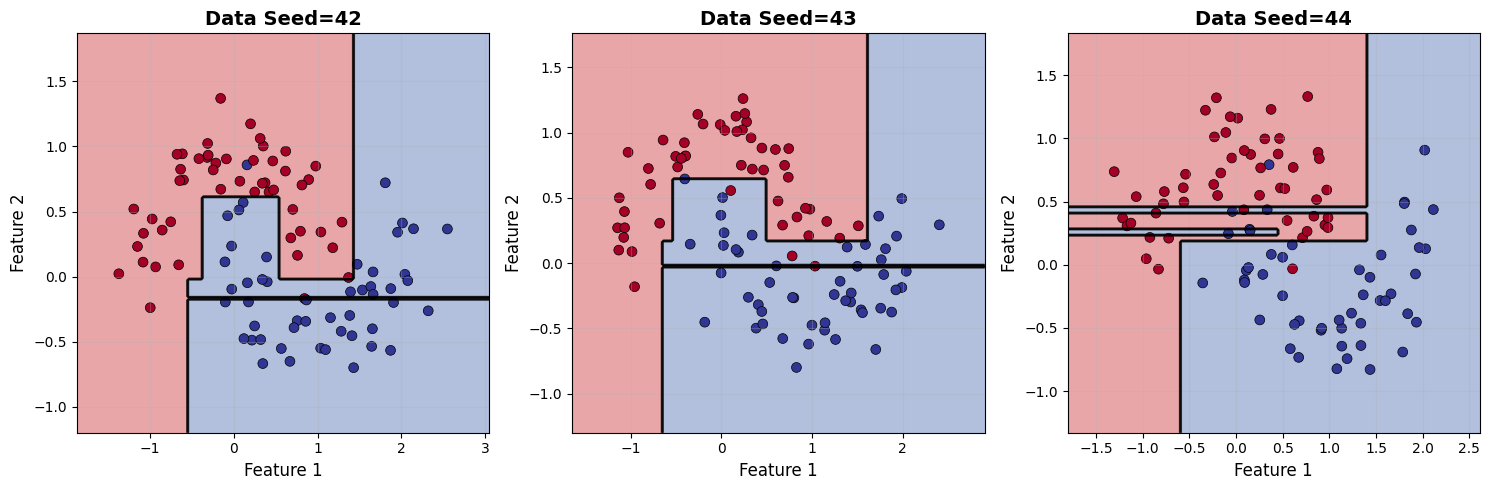

⚠️ High Variance: Small changes in data lead to very different boundaries!
   This is why ensemble methods (Random Forests) are often preferred.


In [17]:
# Demonstrate high variance: small changes lead to different trees
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, seed in enumerate([42, 43, 44]):
    # Generate slightly different data
    X_var, y_var = make_moons(n_samples=100, noise=0.2, random_state=seed)
    
    tree = DecisionTreeClassifier(max_depth=5, random_state=42)
    tree.fit(X_var, y_var)
    
    plot_decision_boundary(
        tree, X_var, y_var,
        f'Data Seed={seed}',
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

print("⚠️ High Variance: Small changes in data lead to very different boundaries!")
print("   This is why ensemble methods (Random Forests) are often preferred.")


## Part 11: Hyperparameter Tuning

Let's do a proper grid search to find the best hyperparameters.


In [18]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.datasets import load_breast_cancer

# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=CONFIG['seed']
)

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Grid search
print("Performing Grid Search with 5-fold Cross-Validation...\n")

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=CONFIG['seed']),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_c, y_train_c)

print(f"✓ Best parameters: {grid_search.best_params_}")
print(f"✓ Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"✓ Test accuracy: {grid_search.score(X_test_c, y_test_c):.4f}")


Performing Grid Search with 5-fold Cross-Validation...

✓ Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
✓ Best CV accuracy: 0.9473
✓ Test accuracy: 0.9561


### Visualize Grid Search Results


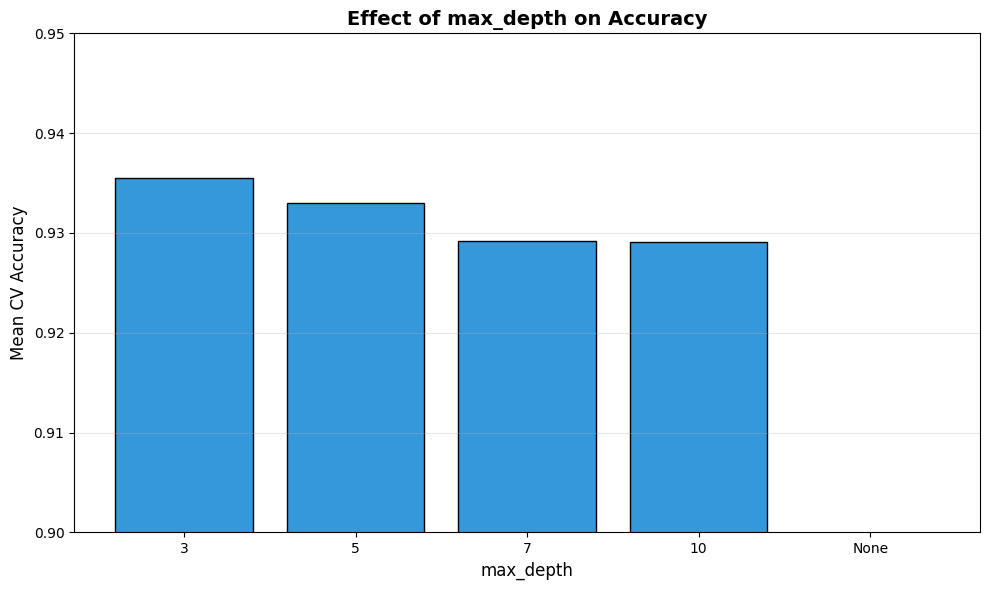

In [19]:
import pandas as pd

# Extract results
results_df = pd.DataFrame(grid_search.cv_results_)

# Plot max_depth effect
plt.figure(figsize=(10, 6))

# Group by max_depth and get mean score
depth_scores = results_df.groupby('param_max_depth')['mean_test_score'].mean()

depths_list = [str(d) if d is not None else 'None' for d in param_grid['max_depth']]
scores_list = [depth_scores.get(d, 0) for d in param_grid['max_depth']]

plt.bar(depths_list, scores_list, color='#3498db', edgecolor='black')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Mean CV Accuracy', fontsize=12)
plt.title('Effect of max_depth on Accuracy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0.9, 0.95)
plt.tight_layout()
plt.show()


## Part 12: Key Takeaways

Congratulations! You now have deep intuitions about Decision Trees.


In [20]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                    KEY TAKEAWAYS                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  1. INTUITION                                                     ║
║     • Trees ask a series of yes/no questions (like 20 Questions)  ║
║     • Each split separates data based on one feature              ║
║     • Leaves contain the final predictions                        ║
║                                                                   ║
║  2. SPLITTING CRITERIA                                            ║
║     • Gini Impurity and Entropy measure "purity" of nodes         ║
║     • Information Gain = reduction in impurity from a split       ║
║     • Tree greedily chooses split with highest information gain   ║
║                                                                   ║
║  3. DECISION BOUNDARIES                                           ║
║     • Always axis-aligned (horizontal/vertical lines)             ║
║     • Need multiple splits for diagonal patterns                  ║
║                                                                   ║
║  4. OVERFITTING                                                   ║
║     • Deep trees memorize training data (including noise!)        ║
║     • Use regularization: max_depth, min_samples_leaf, etc.       ║
║     • Watch the train-test accuracy gap                           ║
║                                                                   ║
║  5. PRACTICAL ADVICE                                              ║
║     • Start with max_depth=5-10 and tune from there               ║
║     • Use cross-validation for hyperparameter tuning              ║
║     • Check feature importances for insights                      ║
║     • Consider Random Forests for better performance              ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║                    KEY TAKEAWAYS                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  1. INTUITION                                                     ║
║     • Trees ask a series of yes/no questions (like 20 Questions)  ║
║     • Each split separates data based on one feature              ║
║     • Leaves contain the final predictions                        ║
║                                                                   ║
║  2. SPLITTING CRITERIA                                            ║
║     • Gini Impurity and Entropy measure "purity" of nodes         ║
║     • Information Gain = reduction in impurity from a split       ║
║     • Tree greedily chooses split with highest information gain   ║
║                                                                   ║
║  3. DECISION BOUNDA

### Summary Table

| Aspect | Key Points |
|--------|------------|
| **How they work** | Recursive binary splits based on feature thresholds |
| **Splitting criteria** | Gini impurity or Entropy (classification), MSE (regression) |
| **Main weakness** | High variance, prone to overfitting |
| **Regularization** | max_depth, min_samples_leaf, min_samples_split |
| **Best for** | Interpretable models, mixed data types, feature selection |
| **Not ideal for** | High-dimensional data, when accuracy is paramount |
| **Next step** | Use ensembles (Random Forests, Gradient Boosting) for better accuracy |


### 🤔 Final Reflection Questions

1. **Why** do decision trees create axis-aligned decision boundaries? What implications does this have?

2. **How** does the tree decide which feature and threshold to split on at each node?

3. **When** would you choose a decision tree over more complex models?

4. **What** happens if you don't regularize a decision tree? How do you know you're overfitting?

5. **Why** are ensemble methods (Random Forests, Gradient Boosting) often preferred over single decision trees?

---

**Well done!** 🎉 You now understand decision trees — the building blocks for some of the most powerful machine learning algorithms!

**Next up**: Explore **Ensemble Methods** to see how combining multiple trees creates dramatically better models.

---

## THE END

Check my repo for more **AI/ML** notebooks: https://github.com/tsilva/aiml-notebooks
